# Task 3: Heart Disease Prediction

**Internship:** AI/ML Engineering Internship — DevelopersHub Corporation  
**Task:** Task 3 — Binary Classification  
**Dataset:** Heart Disease UCI Dataset  

## Objective
Build a model to predict whether a person is at risk of heart disease based on clinical health data. We will train two classification models, evaluate them rigorously, and identify which health factors are most predictive.

## Dataset Features

| Column | Description |
|---|---|
| `age` | Age in years |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–3) |
| `thal` | Thalassemia type (1 = normal, 2 = fixed defect, 3 = reversable defect) |
| `target` | **Heart disease present (1 = yes, 0 = no)** |

## Step 1: Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

# Settings
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

We load the Heart Disease UCI dataset. The preferred method is `ucimlrepo` (no Kaggle login needed). A CSV fallback is also provided.

In [3]:
!pip install ucimlrepo

In [4]:
# --- Method 1: Load via ucimlrepo (recommended, no login needed) ---
try:
    from ucimlrepo import fetch_ucirepo
    heart_repo = fetch_ucirepo(id=45)
    X_raw = heart_repo.data.features
    y_raw = heart_repo.data.targets
    df = pd.concat([X_raw, y_raw], axis=1)
    # Binarize target: original has values 0-4, we collapse to 0 vs 1+
    df.columns = [*X_raw.columns, 'target']
    df['target'] = (df['target'] > 0).astype(int)
    print('Loaded via ucimlrepo.')

except Exception:
    # --- Method 2: Load from CSV (place heart.csv in the same folder) ---
    df = pd.read_csv('heart.csv')
    print('Loaded from heart.csv (fallback).')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Loaded via ucimlrepo.
Shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.300,3,0.000,6.000,0
1,67,1,4,160,286,0,2,108,1,1.500,2,3.000,3.000,1
2,67,1,4,120,229,0,2,129,1,2.600,2,2.000,7.000,1
3,37,1,3,130,250,0,0,187,0,3.500,3,0.000,3.000,0
4,41,0,2,130,204,0,2,172,0,1.400,1,0.000,3.000,0


## Step 3: Data Inspection

In [5]:
# Data types and null check
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [6]:
# Summary statistics
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,299.000,301.000,303.000
mean,54.439,0.680,3.158,131.690,246.693,0.149,0.990,149.607,0.327,1.040,1.601,0.672,4.734,0.459
std,9.039,0.467,0.960,17.600,51.777,0.356,0.995,22.875,0.470,1.161,0.616,0.937,1.940,0.499
min,29.000,0.000,1.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000,0.000
25%,48.000,0.000,3.000,120.000,211.000,0.000,0.000,133.500,0.000,0.000,1.000,0.000,3.000,0.000
50%,56.000,1.000,3.000,130.000,241.000,0.000,1.000,153.000,0.000,0.800,2.000,0.000,3.000,0.000
75%,61.000,1.000,4.000,140.000,275.000,0.000,2.000,166.000,1.000,1.600,2.000,1.000,7.000,1.000
max,77.000,1.000,4.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,3.000,3.000,7.000,1.000


In [7]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

# Class distribution
print('\nClass distribution (target):')
counts = df['target'].value_counts()
print(counts)
print(f'\nDisease prevalence: {counts[1]/len(df)*100:.1f}%')

Missing values per column:
ca      4
thal    2
dtype: int64

Class distribution (target):
target
0    164
1    139
Name: count, dtype: int64

Disease prevalence: 45.9%


## Step 4: Exploratory Data Analysis (EDA)

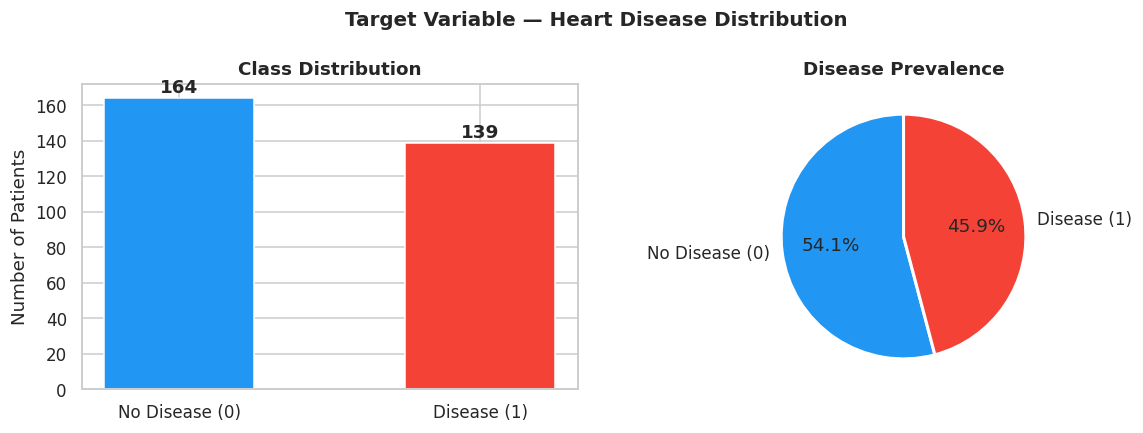

Saved: class_distribution.png


In [8]:
# --- 4.1 Class Balance ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
labels = ['No Disease (0)', 'Disease (1)']
counts_list = [df['target'].value_counts()[0], df['target'].value_counts()[1]]
bars = axes[0].bar(labels, counts_list, color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for bar, count in zip(bars, counts_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(count), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Patients')

# Pie chart
axes[1].pie(counts_list, labels=labels, colors=['#2196F3', '#F44336'],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Disease Prevalence', fontweight='bold')

plt.suptitle('Target Variable — Heart Disease Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

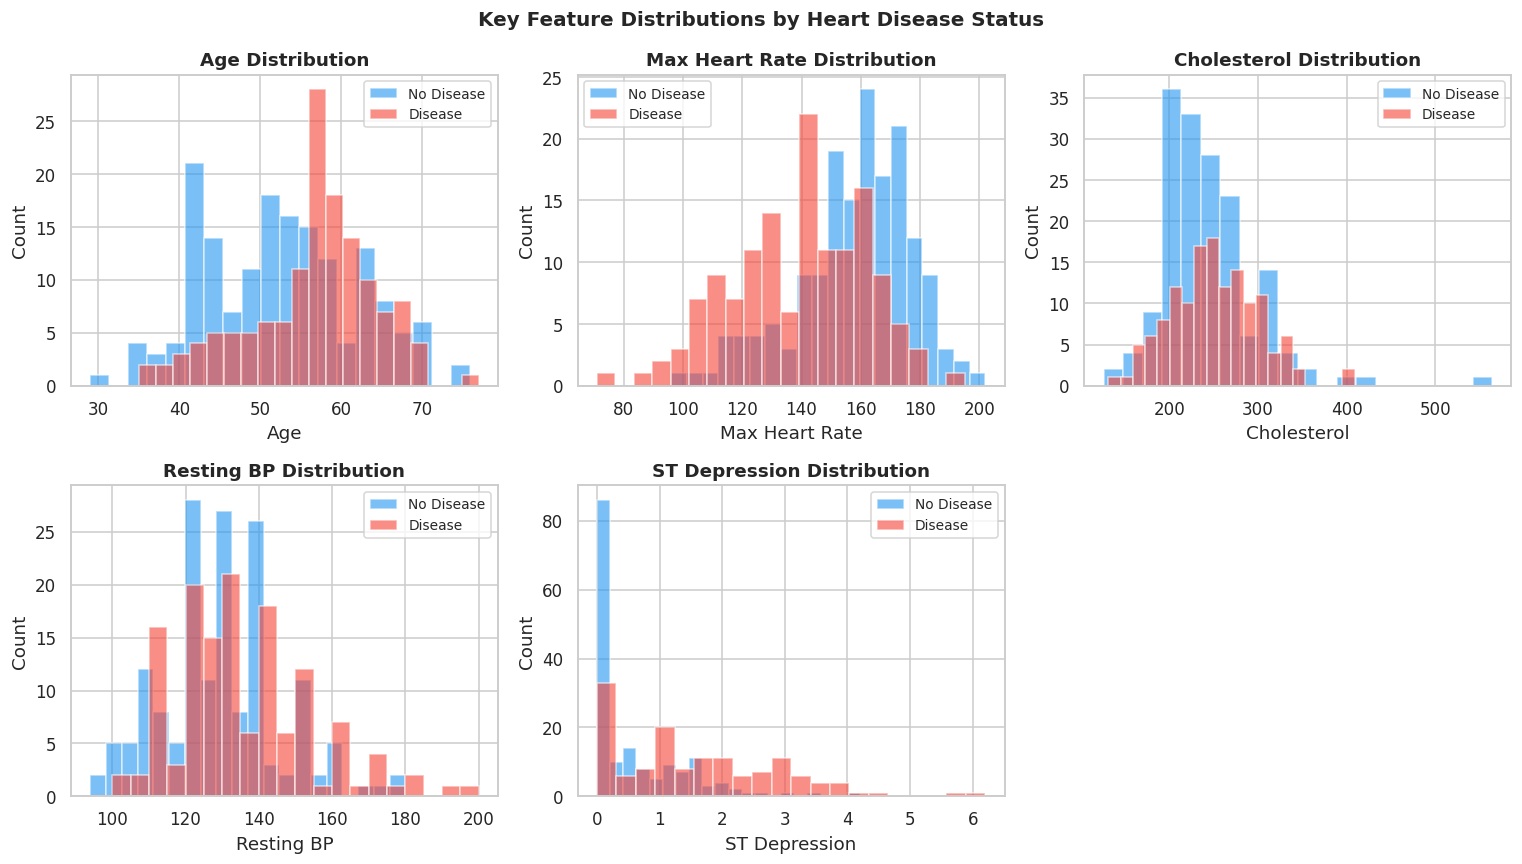

Saved: feature_distributions.png


In [9]:
# --- 4.2 Key Feature Distributions by Target ---
key_features = ['age', 'thalach', 'chol', 'trestbps', 'oldpeak']
feature_labels = ['Age', 'Max Heart Rate', 'Cholesterol', 'Resting BP', 'ST Depression']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(key_features, feature_labels)):
    for val, color, name in [(0, '#2196F3', 'No Disease'), (1, '#F44336', 'Disease')]:
        subset = df[df['target'] == val][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(f'{label} Distribution', fontweight='bold')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

# Hide unused subplot
axes[5].set_visible(False)

plt.suptitle('Key Feature Distributions by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

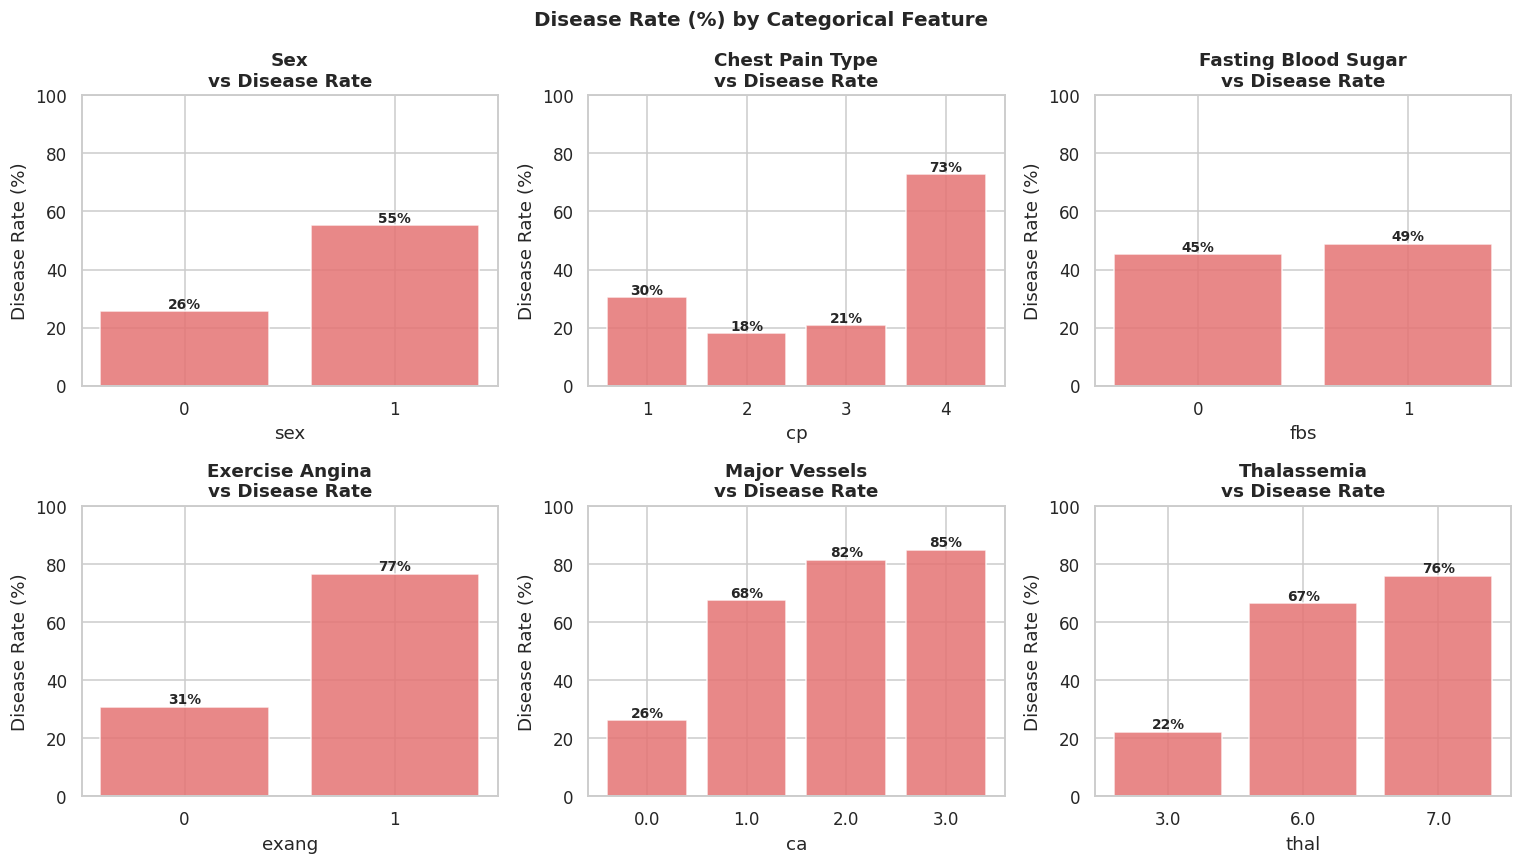

Saved: categorical_analysis.png


In [10]:
# --- 4.3 Categorical Features vs Target ---
cat_features = ['sex', 'cp', 'fbs', 'exang', 'ca', 'thal']
cat_labels   = ['Sex', 'Chest Pain Type', 'Fasting Blood Sugar', 'Exercise Angina', 'Major Vessels', 'Thalassemia']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(cat_features, cat_labels)):
    cross = df.groupby(feat)['target'].mean() * 100  # % with disease
    bars = axes[i].bar(cross.index.astype(str), cross.values,
                       color='#E57373', edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, cross.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(f'{label}\nvs Disease Rate', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Disease Rate (%)')
    axes[i].set_ylim(0, 100)

plt.suptitle('Disease Rate (%) by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: categorical_analysis.png')

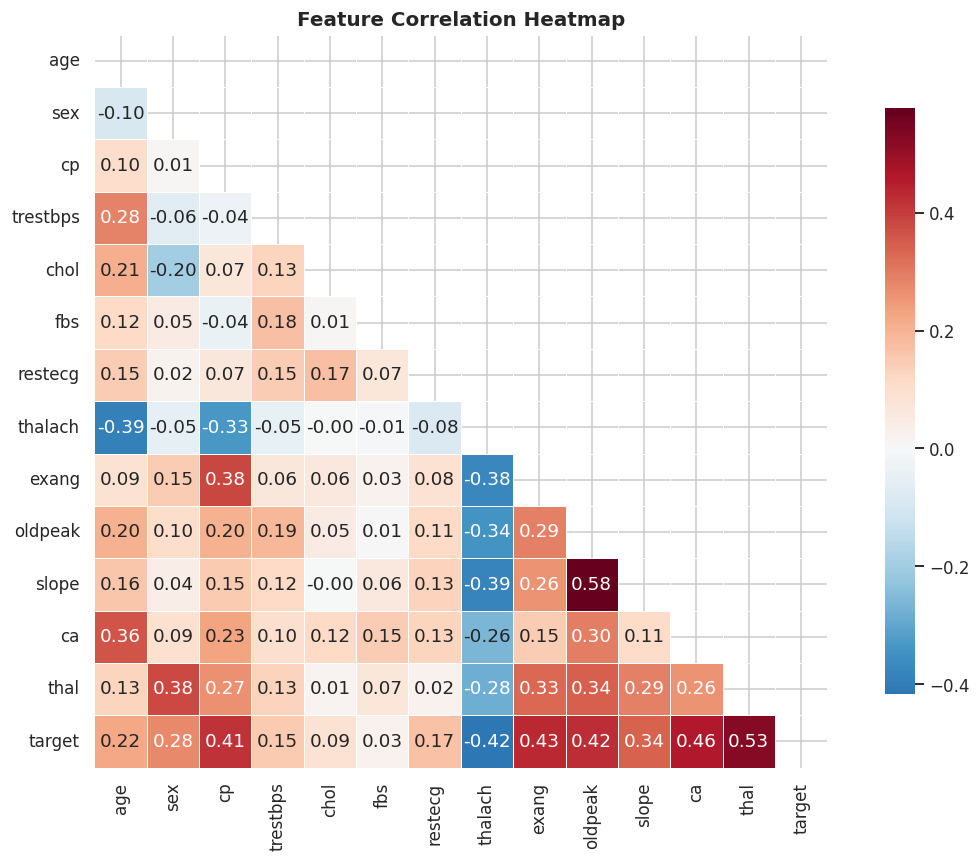

Saved: correlation_heatmap.png


In [11]:
# --- 4.4 Correlation Heatmap ---
plt.figure(figsize=(11, 8))
corr = df.corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

**EDA Insights:**
- `thalach` (max heart rate) is *negatively* correlated with disease — higher max heart rate is associated with healthier hearts.
- `oldpeak`, `ca`, `exang` are positively correlated with disease.
- `cp` (chest pain type) shows strong association — certain pain types are highly predictive.
- `chol` and `trestbps` show less separation between classes than expected.

## Step 5: Preprocessing

This dataset is already mostly clean. We will:
1. Handle any missing values (impute if present)
2. One-hot encode multi-class categorical features
3. Scale numerical features for Logistic Regression

In [13]:
# --- Handle Missing Values ---
if df.isnull().sum().sum() > 0:
    # Numerical: fill with median
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    print('Missing values filled with median.')
else:
    print('No missing values — no imputation needed.')

# --- One-hot encode multi-class categoricals ---
# cp (0-3), thal (1-3), slope (0-2) are ordinal/nominal with multiple values
df_encoded = pd.get_dummies(df, columns=['cp', 'thal', 'slope'], drop_first=True)

print(f'\nShape after encoding: {df_encoded.shape}')
print(f'Columns: {df_encoded.columns.tolist()}')

No missing values — no imputation needed.

Shape after encoding: (303, 18)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_2', 'cp_3', 'cp_4', 'thal_6.0', 'thal_7.0', 'slope_2', 'slope_3']


In [14]:
# --- Split features and target ---
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# --- Train / Test Split (80/20, stratified to preserve class ratio) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples : {len(X_test)}')
print(f'\nClass balance in test set:')
print(y_test.value_counts())

# --- Scale features (for Logistic Regression) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('\nFeature scaling complete (StandardScaler).')

Training samples: 242
Testing samples : 61

Class balance in test set:
target
0    33
1    28
Name: count, dtype: int64

Feature scaling complete (StandardScaler).


## Step 6: Train Classification Models

### Model 1: Logistic Regression
A linear classifier that outputs probabilities. Interpretable and great as a baseline.

In [15]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)

lr_preds      = lr.predict(X_test_sc)
lr_probs      = lr.predict_proba(X_test_sc)[:, 1]  # Probability of class 1
lr_accuracy   = accuracy_score(y_test, lr_preds)
lr_auc        = roc_auc_score(y_test, lr_probs)

# 5-fold cross-validation for reliability
lr_cv_scores  = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='accuracy')

print('=== Logistic Regression ===')
print(f'Test Accuracy  : {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)')
print(f'ROC-AUC Score  : {lr_auc:.4f}')
print(f'CV Accuracy    : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_preds, target_names=['No Disease', 'Disease']))

=== Logistic Regression ===
Test Accuracy  : 0.8525 (85.25%)
ROC-AUC Score  : 0.9556
CV Accuracy    : 0.8262 ± 0.0554

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.82      0.86        33
     Disease       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



### Model 2: Decision Tree Classifier
A tree-based model that splits data based on feature thresholds. Captures non-linear patterns and is easily interpretable.

In [16]:
# Train Decision Tree
dt = DecisionTreeClassifier(
    max_depth=5,          # Limit depth to avoid overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)  # Decision trees don't need scaling

dt_preds    = dt.predict(X_test)
dt_probs    = dt.predict_proba(X_test)[:, 1]
dt_accuracy = accuracy_score(y_test, dt_preds)
dt_auc      = roc_auc_score(y_test, dt_probs)

dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')

print('=== Decision Tree ===')
print(f'Test Accuracy  : {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)')
print(f'ROC-AUC Score  : {dt_auc:.4f}')
print(f'CV Accuracy    : {dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, dt_preds, target_names=['No Disease', 'Disease']))

=== Decision Tree ===
Test Accuracy  : 0.8197 (81.97%)
ROC-AUC Score  : 0.8712
CV Accuracy    : 0.7400 ± 0.0442

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.85      0.84        33
     Disease       0.81      0.79      0.80        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



## Step 7: Evaluation

### 7.1 Confusion Matrices

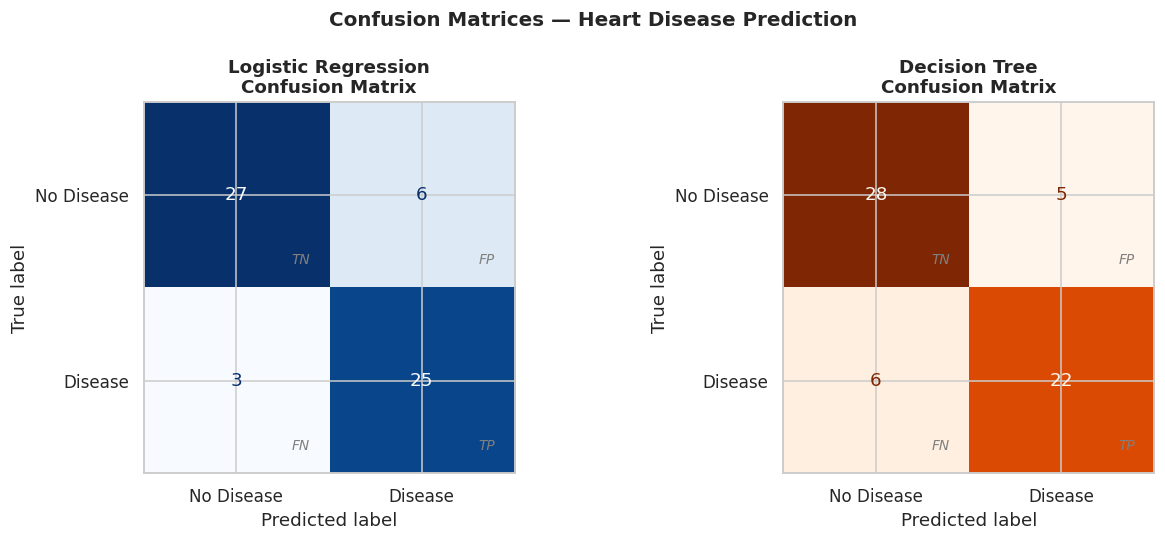

Saved: confusion_matrices.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title, cmap in zip(
    axes,
    [lr_preds, dt_preds],
    ['Logistic Regression', 'Decision Tree'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{title}\nConfusion Matrix', fontweight='bold', fontsize=12)

    # Annotate TP, TN, FP, FN
    labels_map = {(0,0): 'TN', (0,1): 'FP', (1,0): 'FN', (1,1): 'TP'}
    for (row, col), label in labels_map.items():
        ax.text(col + 0.35, row + 0.35, label,
                ha='center', va='center', fontsize=9,
                color='gray', style='italic')

plt.suptitle('Confusion Matrices — Heart Disease Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

### 7.2 ROC Curves

The ROC curve shows the trade-off between True Positive Rate (sensitivity) and False Positive Rate at different thresholds. A higher AUC = better model.

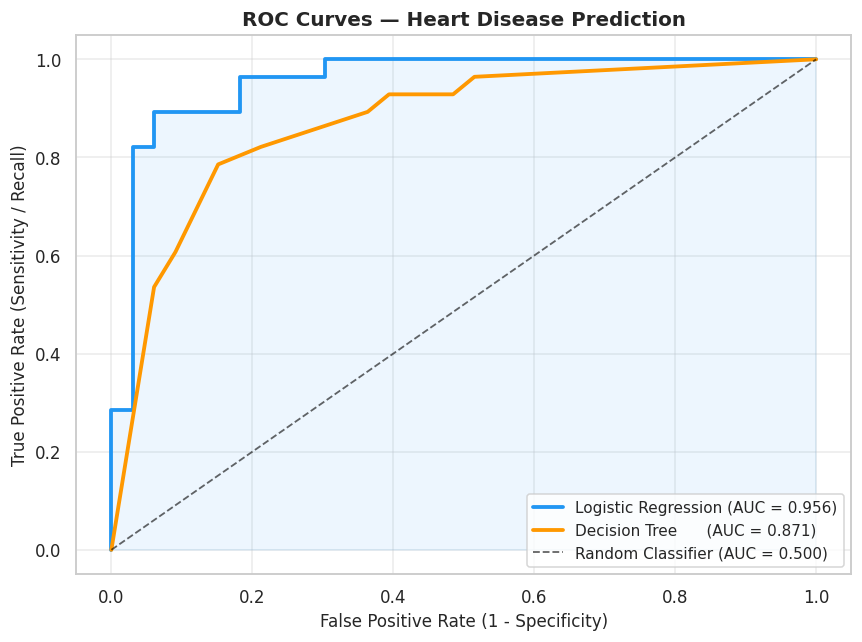

Saved: roc_curves.png


In [18]:
plt.figure(figsize=(8, 6))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, color='#2196F3', linewidth=2.5,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
plt.plot(fpr_dt, tpr_dt, color='#FF9800', linewidth=2.5,
         label=f'Decision Tree      (AUC = {dt_auc:.3f})')

# Random chance baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)', alpha=0.6)

# Shade area under LR curve
plt.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#2196F3')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curves — Heart Disease Prediction', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120)
plt.show()
print('Saved: roc_curves.png')

### 7.3 Model Comparison Summary

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model'        : ['Logistic Regression', 'Decision Tree'],
    'Accuracy'     : [lr_accuracy, dt_accuracy],
    'ROC-AUC'      : [lr_auc, dt_auc],
    'Precision'    : [precision_score(y_test, lr_preds), precision_score(y_test, dt_preds)],
    'Recall'       : [recall_score(y_test, lr_preds),    recall_score(y_test, dt_preds)],
    'F1-Score'     : [f1_score(y_test, lr_preds),        f1_score(y_test, dt_preds)],
    'CV Accuracy'  : [lr_cv_scores.mean(),               dt_cv_scores.mean()]
})

results.set_index('Model', inplace=True)
results = results.round(4)
print(results.to_string())
print('\n→ Higher = better for all metrics.')

                     Accuracy  ROC-AUC  Precision  Recall  F1-Score  CV Accuracy
Model                                                                           
Logistic Regression     0.853    0.956      0.806   0.893     0.848        0.826
Decision Tree           0.820    0.871      0.815   0.786     0.800        0.740

→ Higher = better for all metrics.


## Step 8: Feature Importance

### 8.1 Decision Tree Feature Importances

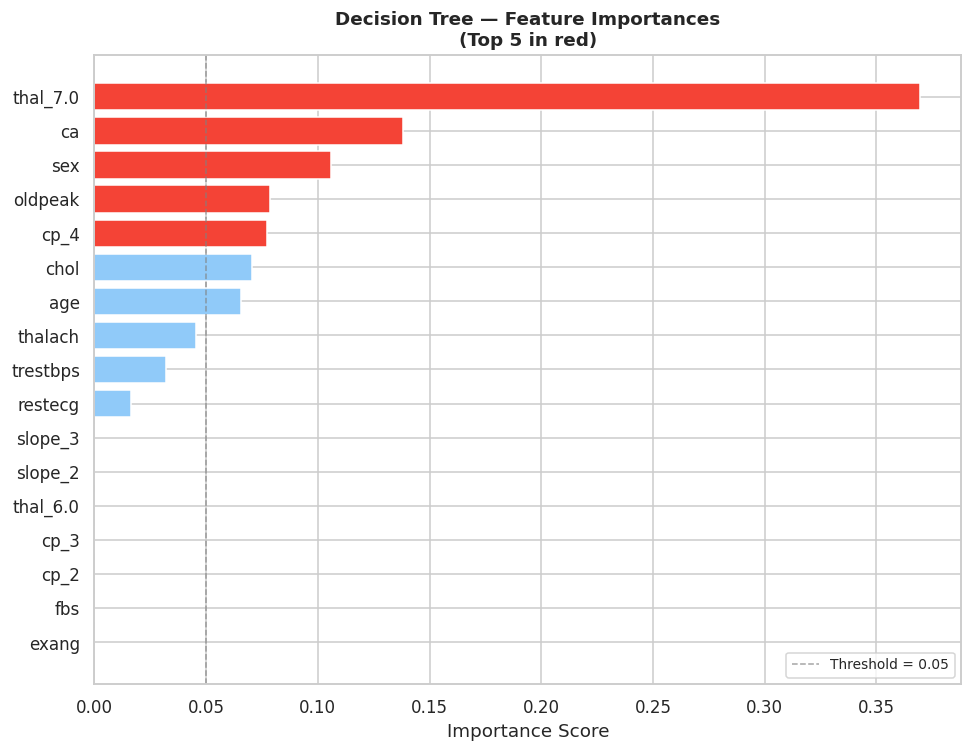

Saved: feature_importance.png

Top 5 Most Predictive Features:
thal_7.0   0.370
ca         0.138
sex        0.106
oldpeak    0.079
cp_4       0.077
dtype: float64


In [20]:
# Extract feature importances from Decision Tree
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

# Color top 5 differently
colors = ['#F44336' if i >= len(importances) - 5 else '#90CAF9'
          for i in range(len(importances))]

plt.figure(figsize=(9, 7))
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='white')
plt.axvline(x=0.05, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Threshold = 0.05')
plt.title('Decision Tree — Feature Importances\n(Top 5 in red)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print('Saved: feature_importance.png')

print('\nTop 5 Most Predictive Features:')
print(importances.sort_values(ascending=False).head())

### 8.2 Logistic Regression Coefficients

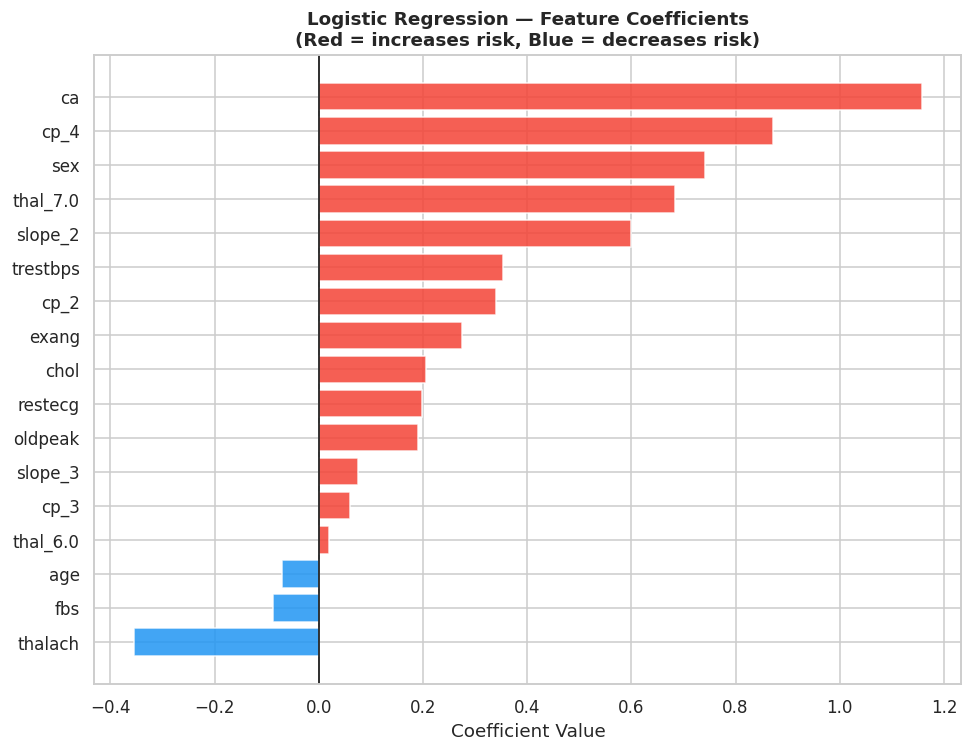

Saved: lr_coefficients.png


In [21]:
# Logistic Regression coefficients (positive = increases disease risk)
coefs = pd.Series(lr.coef_[0], index=X.columns)
coefs = coefs.sort_values()

colors_coef = ['#F44336' if c > 0 else '#2196F3' for c in coefs.values]

plt.figure(figsize=(9, 7))
plt.barh(coefs.index, coefs.values, color=colors_coef, edgecolor='white', alpha=0.85)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Logistic Regression — Feature Coefficients\n(Red = increases risk, Blue = decreases risk)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=120)
plt.show()
print('Saved: lr_coefficients.png')

### 8.3 Decision Tree Visualization

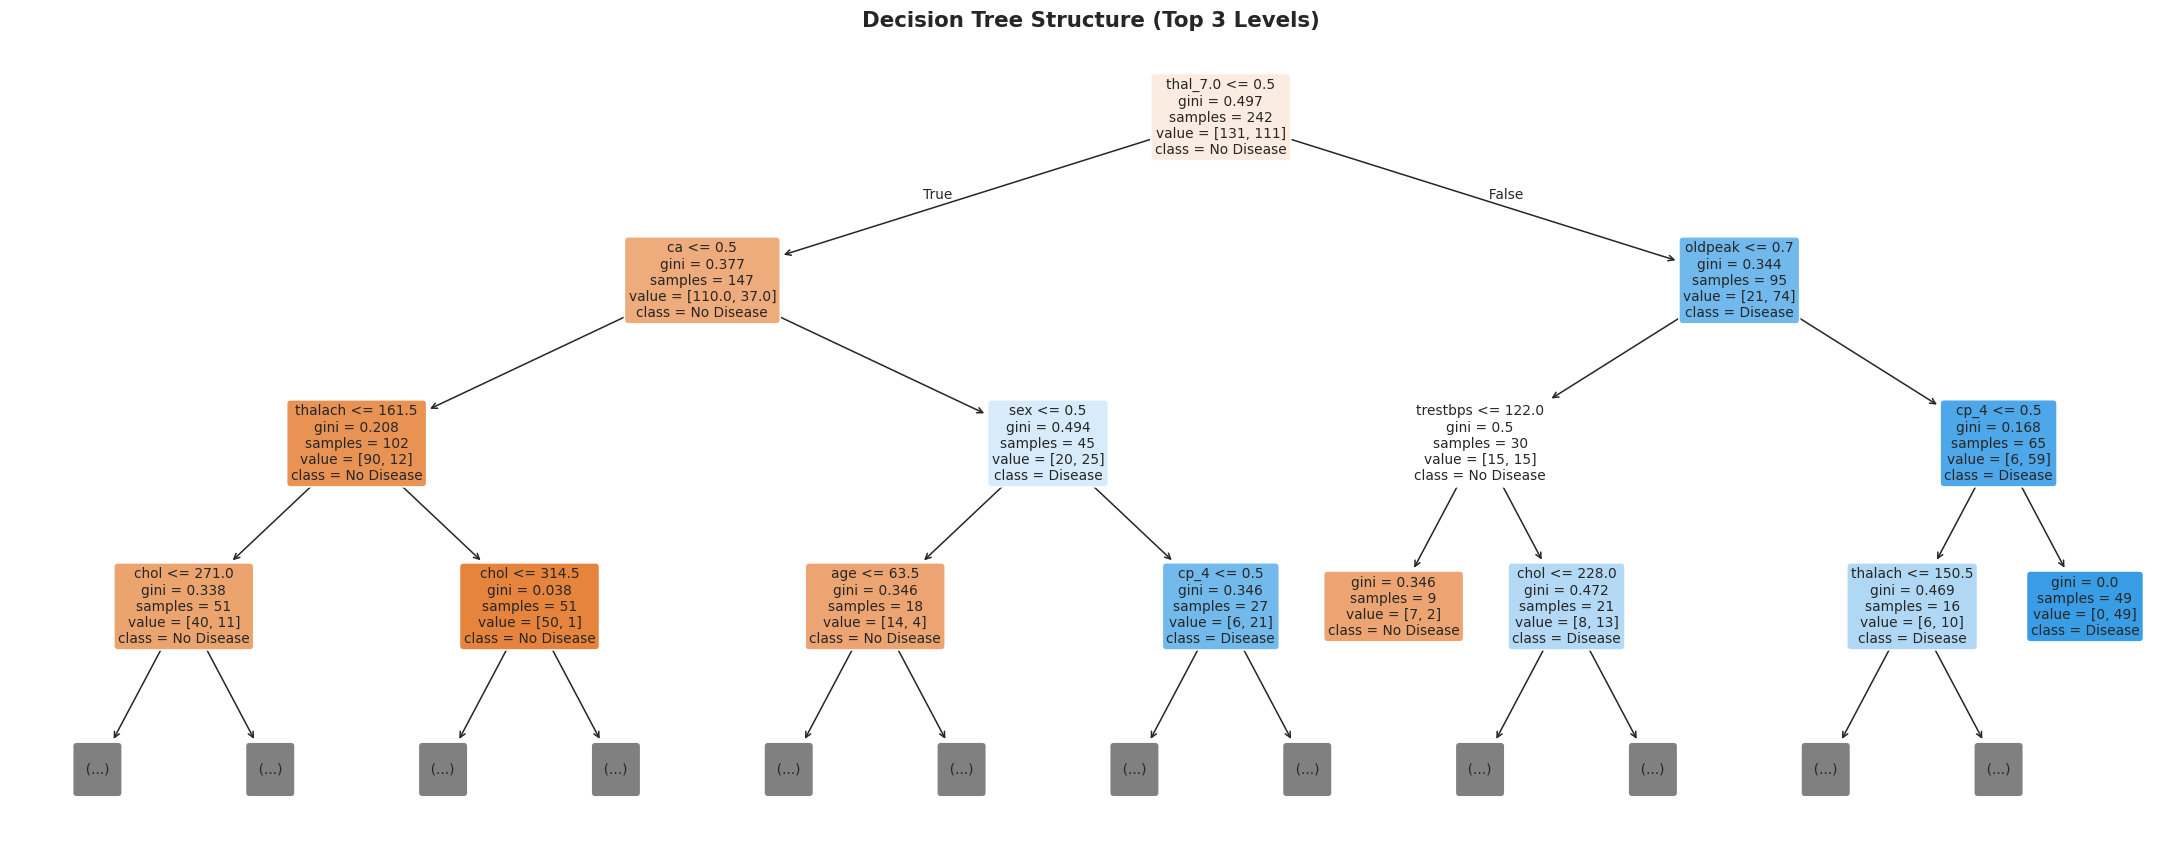

Saved: decision_tree.png


In [22]:
# Visualize the top 3 levels of the Decision Tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=3,             # Show only top 3 levels for readability
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree Structure (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: decision_tree.png')

---
## Step 9: Final Summary and Insights

### Model Performance

| Metric | Logistic Regression | Decision Tree |
|---|---|---|
| Accuracy | See output above | See output above |
| ROC-AUC | See output above | See output above |
| F1-Score | See output above | See output above |

### Key Clinical Findings

1. **Exercise-related features are the strongest predictors:** `thalach` (max heart rate), `exang` (exercise-induced angina), and `oldpeak` (ST depression) — all measurable via a stress test.

2. **Number of major vessels (`ca`) is highly predictive:** More blocked vessels = higher disease risk. This aligns with medical literature.

3. **Chest pain type (`cp`) is surprisingly important:** Asymptomatic chest pain (type 0) does NOT always mean no disease — the type of pain matters.

4. **Cholesterol is less predictive than expected:** `chol` contributes less than lifestyle/stress-test features. This is a known finding in cardiology research.

5. **Both models perform well on this dataset** — Logistic Regression is preferred in clinical settings for interpretability, while Decision Tree is useful for explaining individual decisions.

### Possible Improvements
- Try Random Forest or XGBoost for higher accuracy
- Use SMOTE for class balancing if dataset is imbalanced
- Add hyperparameter tuning with GridSearchCV
- Apply cross-validation more rigorously with stratified K-Fold